In [2]:
import polars as pl

In [3]:
df = pl.scan_csv("abo-images-small/images/metadata/images.csv.gz")

In [4]:
filtered_df = df.filter((pl.col("height") > 1000) & (pl.col("width") > 1000)).collect()

In [8]:
from sentence_transformers import SentenceTransformer

In [9]:
model = SentenceTransformer("clip-ViT-B-32")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [10]:
model.encode(["get shape"]).shape

(1, 512)

## What is the vector size produced by clip-ViT-B-32?


512


## What do ViT, B and 32 mean in the model name?

VIT means Vision Transformer, B is a base model, 32 is a block sizzed used by transformer

## Database setup

In [11]:
from sqlalchemy.engine import URL

In [12]:
db_url = URL.create(
    drivername="postgresql+psycopg",
    username="postgres",
    password="password",
    host="localhost",
    port=5555,
    database="similarity_search_service_db",
)

In [13]:
from sqlalchemy import create_engine

engine = create_engine(db_url)

In [14]:
from pgvector.sqlalchemy import Vector
from sqlalchemy import String
from sqlalchemy.orm import DeclarativeBase, Mapped, mapped_column
from typing import List

In [15]:
class Base(DeclarativeBase):
    __abstract__ = True


class Img(Base):
    __tablename__ = "images"
    __table_args__ = {"extend_existing": True}

    VECTOR_LENGTH: int = 512

    id: Mapped[int] = mapped_column(primary_key=True)
    image_path: Mapped[str] = mapped_column(String(256))
    embedding: Mapped[List[float]] = mapped_column(Vector(VECTOR_LENGTH))


# Create table
Base.metadata.create_all(engine)

## Image vectorization

In [55]:
import joblib
from PIL import Image
from sentence_transformers import SentenceTransformer
from tqdm import tqdm
from itertools import batched
from sqlalchemy.orm import Session

MAX_IMAGES = 200
BATCH_SIZE = joblib.cpu_count(only_physical_cores=True)


def insert_images(engine, images):
    # finish
    with Session(engine) as session:
        session.add_all(images)
        session.commit()


def vectorize_images(engine, model, image_paths):
    print(image_paths)
    with tqdm(total=MAX_IMAGES) as pbar:
        for images_paths_batch in list(
            batched(image_paths[:MAX_IMAGES], BATCH_SIZE)
        ):  # finish (suggestion - use `batched`)
            images = [
                Image.open(f"abo-images-small/images/small/{path}")
                for path in images_paths_batch
            ]

            # calculate embeddings
            image_embeddings = model.encode(images)

            # create Img instances for all images in batch
            imgs = [
                Img(image_path=image_path, embedding=embed)
                for image_path, embed in zip(images_paths_batch, image_embeddings)
            ]

            # insert all batch images
            insert_images(engine, imgs)

            # update pbar
            pbar.update(len(imgs))


vectorize_images(engine, model, filtered_df["path"].to_list())

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)

100%|██████████| 200/200 [00:21<00:00,  9.27it/s]


In [56]:
import matplotlib.pyplot as plt
from sqlalchemy import select


class ImageSearch:
    def __init__(self, engine, model):
        self.engine = engine
        self.model = model

    def __call__(self, image_description: str, k: int):
        found_images = self.find_similar_images(image_description, k)
        # display images
        self.display_images(found_images, k)

    def find_similar_images(self, image_description: str, k: int):
        image_embedding = self.model.encode(
            image_description
        )  # calculate embedding of image_description

        # remember about session and commit
        with Session(self.engine) as session:
            query = (
                select(Img)
                .order_by(Img.embedding.cosine_distance(image_embedding))
                .limit(k)
            )
            result = session.execute(query).scalars().all()

        return [img.image_path for img in result]

    def display_images(self, images, k):
        fig, axes = plt.subplots(1, k, figsize=(15, 5))

        for i, img_path in enumerate(images):
            img = Image.open(f"abo-images-small/images/small/{img_path}")
            axes[i].imshow(img)
            axes[i].axis("off")
            axes[i].set_title(f"Image {i + 1}")

        plt.show()

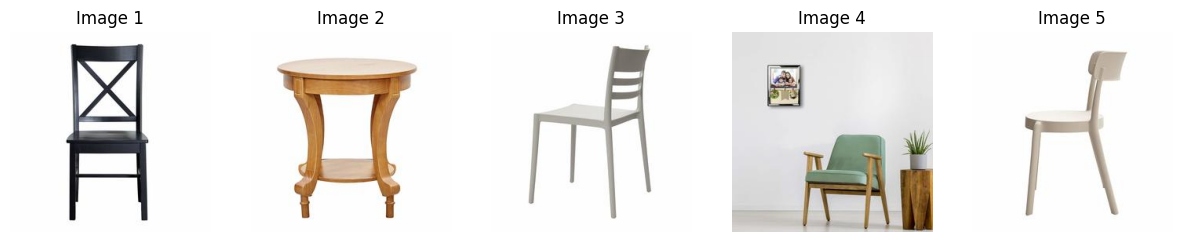

In [59]:
search = ImageSearch(engine, model)
search("old wood chair", k=5)

In [60]:
MAX_IMAGES = 2000
vectorize_images(engine, model, filtered_df["path"].to_list())

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)

100%|██████████| 2000/2000 [03:29<00:00,  9.55it/s]


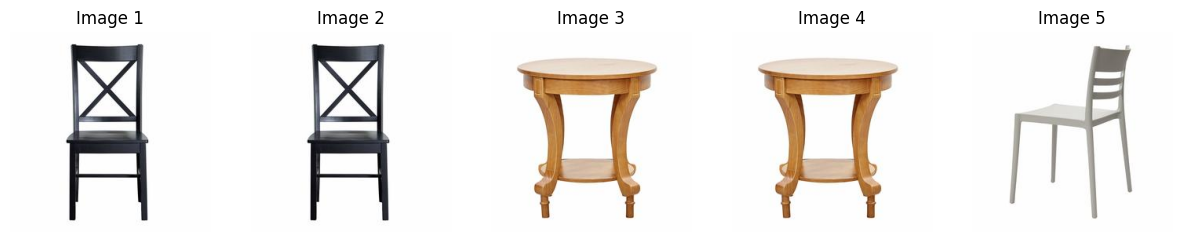

In [61]:
search = ImageSearch(engine, model)
search("old wood chair", k=5)

In [63]:
MAX_IMAGES = 20000
vectorize_images(engine, model, filtered_df["path"].to_list())

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)

100%|██████████| 20000/20000 [33:42<00:00,  9.89it/s]


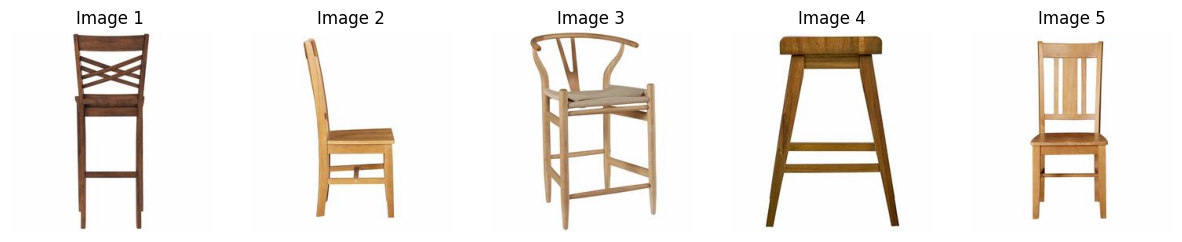

In [72]:
search = ImageSearch(engine, model)
search("old wood chair", k=5)

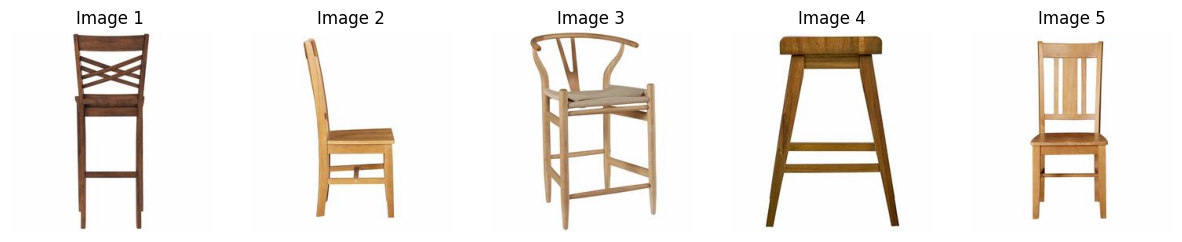

In [81]:
search = ImageSearch(engine, model)
search("Old wood chair", k=5)